# Assessing the Transport Accessibility of Whisky Distilleries from Glasgow

URL: https://github.com/HUA-H124/PTUA-ASSIGNMENT.git

## 1.Introdution

Transport accessibility refers to the ease with which people can reach services, opportunities, and resources through transport networks. It reflects travel conditions, infrastructure provision, and spatial barriers (Lättman, Friman and Olsson, 2024; Rosik, 2022). Accessibility is widely recognised as a key factor shaping tourism flows and destination performance (Yen, Chen and Ho, 2021) It matters not only for the efficient use of urban space, but also for the distribution of economic opportunities and wider regional inequalities.

Cultural and tourism resources have clear spatial attributes, and their practical value is closely related to transport accessibility. Scotch whisky is not only a major economic sector in Scotland, but also an important cultural tourism asset. According to the Scotch Whisky Association (SWA), whisky distilleries in Scotland received around 2.7 million visitors in 2024, which shows that they attract substantial tourist interest (Scotch Whisky Association, 2025).

At the same time, distilleries are not evenly distributed across Scotland. Most of distilleries are located in more remote or peripheral areas, while others are concentrated in particular regions. This uneven pattern raises an important question for urban and regional development: to what extent can these cultural tourism resources be efficiently reached from a major urban centre?

This report focuses on currently operating distilleries and examines their driving accessibility from Glasgow. Glasgow is one of the main population centres and transport hubs in Scotland, and it is also a common starting point for visitors travelling to distilleries. This report addresses three questions. First, how accessible are Scottish operating distilleries from Glasgow in terms of driving distance and travel time? Second, how does this accessibility vary across different parts of Scotland? Third, do these accessibility values display significant spatial clustering?

The report will utilise the distillery list, OpenStreetMap (OSM) spatial data, and Python to conduct data collection, cleaning, feature engineering, and spatial accessibility modelling, explaining from a spatial perspective how transport accessibility affects the distribution of cultural tourism resources and providing a reference for urban and regional planning.

## 2.Data Processing
### 2.1 Geocoding


This report uses two main data sources. The list of distilleries was obtained from the Scotch Whisky Association (SWA), which provides the names of operating distilleries and serves as the foundation for subsequent geocoding and regional classification (Scotch Whisky Association, 2026). Road network data were obtained from OpenStreetMap (OSM), which was also used to support geocoding and later accessibility analysis (OpenStreetMap contributors, 2026). Since reliable and complete visitor-centre data are not readily available in a consistent national dataset, this study uses the SWA list of currently operating distilleries rather than selecting only sites with identified visitor centres. Accordingly, all operating distilleries on the SWA list are treated as a proxy for potential whisky tourism destinations rather than confirmed visitor attractions. If geocoding was conducted through Nominatim and the network was processed in Python using OSMnx, these tools should also be cited in the methods section (Nominatim contributors, 2026; Boeing, 2025).

In [1]:
import re
import pdfplumber
import pandas as pd
from pathlib import Path

# file paths
BASE_DIR = Path(
    r"C:\Users\84966\Desktop\course material\Programming Tools for Urban Analytics\Assignment"
)

PDF_PATH = BASE_DIR / "list-of-current-operating-scotch-whisky-distilleries-for-public-website-june-2025.pdf"
OUTPUT_CSV = BASE_DIR / "scotland_distilleries.csv"

# extract distillery names
def extract_distilleries_from_pdf(pdf_path):

    # check file exists
    if not Path(pdf_path).exists():
        raise FileNotFoundError(f"PDF file not found: {pdf_path}")

    # read the PDF
    all_text = []

    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            text = page.extract_text()
            if text:
                all_text.append(text)

    full_text = "\n".join(all_text)

    # extract all numbered distilleries
    matches = re.findall(
        r"(\d+)\.\s+(.*?)(?=\s+\d+\.|$)",
        full_text,
        flags=re.S
    )

    records = []

    for number, name in matches:
        number = int(number)

        # clean whitespace
        name = re.sub(r"\s+", " ", name).strip()

        # remove accidental backticks from extraction
        name = name.replace("`", "")

        records.append({
            "number": number,
            "distillery_name": name
        })

    # create dataframe
    df = pd.DataFrame(records)

    # remove duplicates
    df = df.drop_duplicates(subset=["number", "distillery_name"])

    # sort by number to restore the correct order
    df = df.sort_values("number").reset_index(drop=True)

    return df

# run extraction
distilleries_df = extract_distilleries_from_pdf(PDF_PATH)
# save CSV
distilleries_df.to_csv(
    OUTPUT_CSV,
    index=False,
    encoding="utf-8-sig"
)

print("Total distilleries:", len(distilleries_df))
print("CSV saved to:")
print(OUTPUT_CSV)

Total distilleries: 152
CSV saved to:
C:\Users\84966\Desktop\course material\Programming Tools for Urban Analytics\Assignment\scotland_distilleries.csv


The distillery list was extracted from the SWA document using pdfplumber. The distillery names were identified through regular expressions based on the numbered format of the document. After removing duplicates and restoring the original order, the extracted data were saved as an file. This process produced a total of 152 distilleries.

### 2.2 Input Coordinates

In [2]:
import re
import time
import pandas as pd
from pathlib import Path
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut, GeocoderServiceError
from tqdm import tqdm
from pyproj import Transformer

# file paths
BASE_DIR = Path(
    r"C:\Users\84966\Desktop\course material\Programming Tools for Urban Analytics\Assignment"
)
INPUT_CSV = BASE_DIR / "scotland_distilleries.csv"
OUTPUT_CSV = BASE_DIR / "scotland_distilleries_geocoded.csv"

# geocoder
geolocator = Nominatim(
    user_agent="UrbanAnalyticsAssignment/1.0 (yourname@university.ac.uk)"
)

# coordinate transformer: WGS84 -> British National Grid
transformer = Transformer.from_crs("EPSG:4326", "EPSG:27700", always_xy=True)

# name cleaning
def normalize_name(name):
    name = str(name).strip()
    name = name.replace("’", "'")
    name = name.replace("`", "")
    name = name.replace("‘", "'")
    name = name.replace("Uile -bheist", "Uile-bheist")
    name = name.replace("Uile- bheist", "Uile-bheist")
    name = re.sub(r"\s+", " ", name).strip()
    return name

def build_query_candidates(name):
    name = normalize_name(name)
    candidates = []
    candidates.append(f"{name}, Scotland")
    candidates.append(f"{name}, whisky distillery, Scotland")
    candidates.append(f"{name}, whiskey distillery, Scotland")

    simplified = re.sub(r",\s*The Distillery", "", name, flags=re.IGNORECASE)
    if simplified != name:
        candidates.append(f"{simplified} Distillery, Scotland")
        candidates.append(f"{simplified} whisky distillery, Scotland")

    simplified2 = re.sub(
        r"\bThe Distillery\b", "Distillery", name, flags=re.IGNORECASE
    )
    if simplified2 != name:
        candidates.append(f"{simplified2}, Scotland")
        candidates.append(f"{simplified2}, whisky distillery, Scotland")

    simplified3 = re.sub(
        r"Distilling Co Distillery", "Distilling Co", name, flags=re.IGNORECASE
    )
    if simplified3 != name:
        candidates.append(f"{simplified3}, Scotland")
        candidates.append(f"{simplified3} distillery, Scotland")

    if "Loch Lomond Grain Distillery" in name:
        candidates.append("Loch Lomond distillery, Alexandria, Scotland")
        candidates.append("Loch Lomond Grain, Scotland")

    if "Loch Lomond Malt Distillery" in name:
        candidates.append("Loch Lomond distillery, Alexandria, Scotland")
        candidates.append("Loch Lomond Malt, Scotland")

    if "Ncn'ean" in name or "Nc'nean" in name:
        candidates.append("Nc'nean Distillery, Scotland")
        candidates.append("Ncnean Distillery, Scotland")

    unique_candidates = []
    seen = set()

    for q in candidates:
        q = re.sub(r"\s+", " ", q).strip()
        if q not in seen:
            seen.add(q)
            unique_candidates.append(q)

    return unique_candidates

# build short address
def build_short_address(address_dict):
    town = (
        address_dict.get("town")
        or address_dict.get("city")
        or address_dict.get("village")
        or address_dict.get("hamlet")
        or address_dict.get("suburb")
    )

    county = (
        address_dict.get("county")
        or address_dict.get("state_district")
        or address_dict.get("state")
    )

    road = address_dict.get("road")

    if town and county:
        return f"{town}, {county}"
    elif road and town:
        return f"{road}, {town}"
    elif town:
        return town
    elif county:
        return county
    else:
        return None

# convert lon/lat to British National Grid
def to_bng(longitude, latitude):
    if pd.isna(longitude) or pd.isna(latitude):
        return None, None
    easting, northing = transformer.transform(longitude, latitude)
    return easting, northing

# geocode one distillery
def geocode_with_fallbacks(distillery_name):
    queries = build_query_candidates(distillery_name)

    for query in queries:
        try:
            location = geolocator.geocode(
                query,
                country_codes="gb",
                exactly_one=True,
                timeout=30,
                addressdetails=True,
            )

            time.sleep(1.1)

            if location is not None:
                address_dict = location.raw.get("address", {})

                short_address = build_short_address(address_dict)
                postcode = address_dict.get("postcode")
                latitude = location.latitude
                longitude = location.longitude
                easting, northing = to_bng(longitude, latitude)

                return {
                    "short_address": short_address,
                    "postcode": postcode,
                    "easting": easting,
                    "northing": northing,
                }

        except (GeocoderTimedOut, GeocoderServiceError):
            time.sleep(1.1)

        except Exception:
            time.sleep(1.1)

    return {
        "short_address": None,
        "postcode": None,
        "easting": None,
        "northing": None,
    }

# main function
def main():
    if not INPUT_CSV.exists():
        raise FileNotFoundError(f"Input CSV not found: {INPUT_CSV}")

    df = pd.read_csv(INPUT_CSV)

    if "distillery_name" not in df.columns:
        raise ValueError(
            "The input CSV must contain a 'distillery_name' column."
        )

    df["distillery_name"] = df["distillery_name"].astype(str).apply(
        normalize_name
    )

    short_addresses = []
    postcodes = []
    eastings = []
    northings = []

    print("\nStarting geocoding...\n")

    for name in tqdm(df["distillery_name"], desc="Geocoding distilleries"):
        result = geocode_with_fallbacks(name)

        short_addresses.append(result["short_address"])
        postcodes.append(result["postcode"])
        eastings.append(result["easting"])
        northings.append(result["northing"])

    df["address"] = short_addresses
    df["postcode"] = postcodes
    df["easting"] = eastings
    df["northing"] = northings
    df["crs"] = "EPSG:27700"
    df = df[
        [
            "number",
            "distillery_name",
            "address",
            "postcode",
            "easting",
            "northing",
            "crs",
        ]
    ]

    df.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")

    unmatched = df[df["easting"].isna() | df["northing"].isna()]

    print("\nGeocoding completed.")
    print(f"Output saved to: {OUTPUT_CSV}")
    print(f"Matched: {len(df) - len(unmatched)}")
    print(f"Unmatched: {len(unmatched)}")

if __name__ == "__main__":
    main()


Starting geocoding...



Geocoding distilleries: 100%|██████████| 152/152 [04:03<00:00,  1.60s/it]


Geocoding completed.
Output saved to: C:\Users\84966\Desktop\course material\Programming Tools for Urban Analytics\Assignment\scotland_distilleries_geocoded.csv
Matched: 137
Unmatched: 15


Distillery locations were first geocoded automatically using the Nominatim service based on OSM data. To improve the match rate, distillery names were cleaned and multiple search queries were generated for each site. Distilleries that could not be matched automatically were then checked manually using Google Maps and other online location references. The resulting coordinates were converted from WGS84 to the British National Grid to ensure consistency in subsequent spatial analysis.

In [3]:
import re
import time
import pandas as pd
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut, GeocoderServiceError
from tqdm import tqdm
from pyproj import Transformer

# geocoder
geolocator = Nominatim(user_agent="distillery_project")

# coordinate transformer: WGS84 -> British National Grid
transformer = Transformer.from_crs("EPSG:4326", "EPSG:27700", always_xy=True)

# functions
def extract_postcode(text):
    postcode_pattern = r"[A-Z]{1,2}\d[A-Z\d]?\s?\d[A-Z]{2}"
    match = re.search(postcode_pattern, str(text).upper())
    return match.group(0) if match else None

def extract_short_address_from_input(address):
    """
    Keep only the useful location part from the manually collected address.
    Uses the input address, not the geocoded result.
    """
    postcode = extract_postcode(address)

    short = address
    if postcode:
        short = short.replace(postcode, "")

    short = short.replace(", Scotland", "").replace("Scotland", "")
    parts = [p.strip() for p in short.split(",") if p.strip()]

    drop_prefixes = [
        "Ladywell Ave",
        "Bankfoot Farm",
        "Benbecula Distillery",
        "Balmacassie Commercial Park",
        "Units 10-13",
        "The Cairn Distillery",
        "Wester Greens",
        "48 High St",
        "Lochlea Distillery",
        "Lochlea Farm",
        "Forss Business and Energy Park",
        "Block 1",
        "Starlaw Rd"
    ]

    while parts and any(parts[0].startswith(prefix) for prefix in drop_prefixes):
        parts.pop(0)

    if len(parts) >= 2:
        short_address = ", ".join(parts[-2:])
    elif len(parts) == 1:
        short_address = parts[0]
    else:
        short_address = None

    return short_address, postcode

def to_bng(longitude, latitude):
    """
    Convert WGS84 longitude/latitude to British National Grid.
    Returns easting, northing.
    """
    if pd.isna(longitude) or pd.isna(latitude):
        return None, None

    easting, northing = transformer.transform(longitude, latitude)
    return easting, northing

def geocode_with_fallbacks(full_address, postcode):
    """
    Try full address first.
    If that fails, try postcode only.
    Returns British National Grid coordinates.
    """
    queries = []

    if pd.notna(full_address):
        queries.append(full_address)

    if pd.notna(postcode):
        queries.append(f"{postcode}, Scotland")
        queries.append(postcode)

    for query in queries:
        try:
            location = geolocator.geocode(query, timeout=30)
            time.sleep(1)

            if location:
                latitude = location.latitude
                longitude = location.longitude
                easting, northing = to_bng(longitude, latitude)
                return easting, northing

        except (GeocoderTimedOut, GeocoderServiceError):
            time.sleep(1)
            continue
        except Exception:
            time.sleep(1)
            continue

    return None, None

# manual address table
manual_data = [
    ["Ailsa Bay Distillery", "Ladywell Ave, Girvan KA26 9PF, Scotland"],
    ["Ardgowan Distillery", "Bankfoot Farm, Inverkip, Greenock PA16 0DT, Scotland"],
    ["Balmaud Distillery", "Turriff AB53 5PT, Scotland"],
    ["Benbecula Distillery", "Benbecula Distillery, Gramsdale HS7 5QP, Scotland"],
    ["BrewDog Distilling Co Distillery", "Balmacassie Commercial Park, Ellon AB41 8BX, Scotland"],
    ["Burn o'Bennie Distillery", "Units 10-13, Burn O'Bennie Distillery, Burn O'Bennie Business Park, Burn O'Bennie Rd, Banchory AB31 5NN, Scotland"],
    ["Cairn Distillery, The Distillery", "The Cairn Distillery, Grantown-on-Spey PH26 3NT, Scotland"],
    ["Dunphail Distillery", "Wester Greens, Dunphail, Forres IV36 2QR, Scotland"],
    ["Glen Spey Distillery", "48 High St, Rothes, Aberlour AB38 7AY, Scotland"],
    ["Kininvie Distillery", "Dufftown AB55 4DH, Scotland"],
    ["Lochlea Distillery", "Lochlea Distillery, Lochlea Farm, Kilmarnock KA1 5NN, Scotland"],
    ["Lochranza Distillery", "Lochranza, Isle of Arran KA27 8HJ, Scotland"],
    ["North Point Distillery", "Forss Business and Energy Park, Thurso KW14 7UZ, Scotland"],
    ["Reivers Distillery", "Block 1, Tweedbank Industrial Estate, Tweedbank, Galashiels TD1 3RS, Scotland"],
    ["Starlaw Distillery", "Starlaw Rd, Bathgate EH47 7BW, Scotland"]
]

manual_df = pd.DataFrame(
    manual_data,
    columns=["distillery_name", "input_address"]
)

# process
clean_addresses = []
postcodes = []
eastings = []
northings = []

print("\nStarting manual geocoding...\n")

for input_address in tqdm(manual_df["input_address"], desc="Manual distilleries"):
    short_address, postcode = extract_short_address_from_input(input_address)
    easting, northing = geocode_with_fallbacks(input_address, postcode)

    clean_addresses.append(short_address)
    postcodes.append(postcode)
    eastings.append(easting)
    northings.append(northing)

manual_df["address"] = clean_addresses
manual_df["postcode"] = postcodes
manual_df["easting"] = eastings
manual_df["northing"] = northings
manual_df["crs"] = "EPSG:27700"

# keep only useful columns
manual_df = manual_df[
    [
        "distillery_name",
        "address",
        "postcode",
        "easting",
        "northing",
        "crs"
    ]
]

manual_df.to_csv(
    "manual_distillery_coordinates.csv",
    index=False,
    encoding="utf-8-sig"
)

# summary
unmatched = manual_df[
    manual_df["easting"].isna() |
    manual_df["northing"].isna()
]

print("\nManual geocoding completed.")
print(f"Matched: {len(manual_df) - len(unmatched)}")
print(f"Unmatched: {len(unmatched)}")
print("\nSaved to: manual_distillery_coordinates.csv")


Starting manual geocoding...



Manual distilleries: 100%|██████████| 15/15 [00:32<00:00,  2.15s/it]


Manual geocoding completed.
Matched: 15
Unmatched: 0

Saved to: manual_distillery_coordinates.csv


Some distilleries could not be directly matched through the OSM-based API search, because of naming ambiguity, incomplete address information, or limited recognition by the geocoding service. To solve this problem, the missing 15 distilleries were manually checked using Google Maps to find their addresses. The two-stage geocoding improved the completeness of the dataset while maintaining a consistent coordinate reference system for all observations.

### 2.3 Merge Dataset

In [4]:
# file paths
geocoded_file = "scotland_distilleries_geocoded.csv"
manual_file = "manual_distillery_coordinates.csv"
output_file = "scotland_distilleries_fully_merged.csv"

# load source files
df_geocoded = pd.read_csv(geocoded_file)
df_manual = pd.read_csv(manual_file)

# merge all useful fields from the manual file
df_merged = df_geocoded.merge(
    df_manual[["distillery_name", "address", "postcode", "easting", "northing", "crs"]],
    on="distillery_name",
    how="left",
    suffixes=("", "_manual")
)

# fill missing values in the main file using the manual file
for column in ["address", "postcode", "easting", "northing", "crs"]:
    df_merged[column] = df_merged[column].fillna(df_merged[f"{column}_manual"])

# drop temporary columns created by the merge
df_merged = df_merged.drop(columns=[
    "address_manual",
    "postcode_manual",
    "easting_manual",
    "northing_manual",
    "crs_manual"
])

# save merged result
df_merged.to_csv(output_file, index=False, encoding="utf-8-sig")

# check only coordinate missing (important for spatial analysis)
missing_coords = df_merged[
    df_merged[["easting", "northing"]].isna().any(axis=1)
]

# concise output
print("Merge completed.")
print(f"Saved merged file to: {output_file}")
print(f"Total rows: {len(df_merged)}")
print(f"Rows missing coordinates: {len(missing_coords)}")

if len(missing_coords) == 0:
    print("All distilleries successfully geocoded.")

Merge completed.
Saved merged file to: scotland_distilleries_fully_merged.csv
Total rows: 152
Rows missing coordinates: 0
All distilleries successfully geocoded.


After both automated and manual geocoding had been completed, the two datasets were merged into a file. The automatically geocoded dataset served as the main table, while the manually completed file was used to fill missing values.

In [5]:
import re
from IPython.display import display

# load distillery dataset
input_file = "scotland_distilleries_fully_merged.csv"
df = pd.read_csv(input_file)
name_col = "distillery_name"
if name_col not in df.columns:
    raise ValueError(f"Column '{name_col}' not found in the dataset")

# normalize names
def normalize_name(name):
    if pd.isna(name):
        return ""

    name = str(name).upper().strip()

    # remove punctuation
    name = re.sub(r"[’'`.,()/\-]", " ", name)
    name = re.sub(r"\s+", " ", name).strip()

    # remove generic words
    generic_tokens = [
        "DISTILLERY",
        "DISTILLERIES",
        "DISTILLERS",
        "COMPANY",
        "THE",
    ]
    words = [w for w in name.split() if w not in generic_tokens]
    name = " ".join(words)

    # alias mapping for known naming variants
    alias_map = {
        "BREWDOG DISTILLING CO": "BREWDOG DISTILLING",
        "BREWDOG DISTILLING CO DISTILLERY": "BREWDOG DISTILLING",
        "BREWDOG DISTILLING": "BREWDOG DISTILLING",
        "NCN EAN": "NCNEAN",
        "NC NEAN": "NCNEAN",
        "NCNEAN": "NCNEAN",
        "ALLT A BHAINNE": "ALLT A BHAINNE",
        "GLENALLACHIE": "GLENALLACHIE",
        "GLENWYVIS": "GLENWYVIS",
        "INCHDAIRNIE": "INCHDAIRNIE",
        "UILE BHEIST": "UILE BHEIST",
        "BURN O BENNIE": "BURN O BENNIE",
        "GLEN SCOTIA": "GLEN SCOTIA",
        "PORT OF LEITH": "PORT OF LEITH",
        "LOCH LOMOND MALT": "LOCH LOMOND MALT",
        "LOCH LOMOND GRAIN": "LOCH LOMOND GRAIN",
    }

    return alias_map.get(name, name)

df["name_norm"] = df[name_col].apply(normalize_name)

# region lists
islay_list = [
    "Ardbeg", "Ardnahoe", "Bowmore", "Bruichladdich", "Bunnahabhain",
    "Caol Ila", "Kilchoman", "Lagavulin", "Laphroaig", "Port Ellen"
]

campbeltown_list = [
    "Glen Scotia", "Glengyle", "Springbank"
]

highland_list = [
    "8 Doors", "Aberfeldy", "Arbikie", "Ardmore", "Ardnamurchan",
    "Ardross", "Balblair", "Balmaud", "Ben Nevis", "Benbecula",
    "Blair Athol", "BrewDog Distilling", "Brora", "Burn O Bennie",
    "Clynelish", "Dalmore", "Dalwhinnie", "Deanston", "Dornoch",
    "Eden Mill", "Edradour", "Fettercairn", "Glen Garioch", "Glen Ord",
    "Glencadam", "Glendronach", "Glenglassaugh", "Glengoyne",
    "Glenmorangie", "Glenturret", "GlenWyvis", "Highland Park",
    "Isle of Harris", "Isle of Jura", "Isle of Raasay", "Isle of Tiree",
    "Lagg", "Loch Lomond Malt", "Lochranza", "Macduff", "Ncnean",
    "North Point", "Oban", "Orkney", "Pulteney", "Royal Brackla",
    "Royal Lochnagar", "Scapa", "Strathearn", "Talisker", "Teaninich",
    "Tobermory", "Tomatin", "Torabhaig", "Tullibardine",
    "Uile-bheist", "Wolfburn"
]

speyside_list = [
    "Aberlour", "Allt a Bhainne", "Auchroisk", "Aultmore", "Ballindalloch",
    "Balmenach", "Balvenie", "BenRiach", "Benrinnes", "Benromach",
    "Braeval", "Cairn", "Cardhu", "Cragganmore", "Craigellachie",
    "Dailuaine", "Dalmunach", "Dufftown", "Dunphail", "Glen Elgin",
    "Glen Grant", "Glen Keith", "Glen Moray", "Glen Spey", "GlenAllachie",
    "Glenburgie", "Glendullan", "Glenfarclas", "Glenfiddich",
    "Glenlivet", "Glenlossie", "Glenrothes", "Glentauchers",
    "Inchgower", "Kininvie", "Knockando", "Knockdhu", "Linkwood",
    "Longmorn", "Macallan", "Mannochmore", "Miltonduff", "Mortlach",
    "Roseisle", "Speyburn", "Strathisla", "Strathmill", "Tamdhu",
    "Tamnavulin", "Tomintoul", "Tormore"
]

lowland_list = [
    "Aberargie", "Ailsa Bay", "Annandale", "Ardgowan", "Auchentoshan",
    "Bladnoch", "Bonnington", "Borders", "Clydeside", "Crafty",
    "Daftmill", "Falkirk", "Glasgow Distillery", "Glenkinchie",
    "Holyrood", "InchDairnie", "Jackton", "Kingsbarns",
    "Lindores Abbey", "Lochlea", "Port of Leith", "Rosebank", "Stirling"
]

grain_list = [
    "Cameronbridge", "Girvan", "Invergordon", "Loch Lomond Grain",
    "North British", "Reivers", "Starlaw", "Strathclyde"
]

region_lists_raw = {
    "Islay": islay_list,
    "Campbeltown": campbeltown_list,
    "Highland": highland_list,
    "Speyside": speyside_list,
    "Lowland": lowland_list,
    "Grain Whisky": grain_list,
}

region_lists = {
    region: [normalize_name(x) for x in names]
    for region, names in region_lists_raw.items()
}

# create lookup table
distillery_to_region = {}
for region, names in region_lists.items():
    for name in names:
        distillery_to_region[name] = region

# assign region
def assign_region(name_norm):
    return distillery_to_region.get(name_norm, "Unmatched")

df["region"] = df["name_norm"].apply(assign_region)

# summary table
summary_df = (
    df["region"]
    .value_counts(dropna=False)
    .rename_axis("region")
    .reset_index(name="count")
)

summary_df.index = summary_df.index + 1

# unmatched only
unmatched_df = (
    df[df["region"] == "Unmatched"][[name_col, "name_norm", "region"]]
    .sort_values(name_col)
    .reset_index(drop=True)
)
unmatched_df.index = unmatched_df.index + 1

# optional: save classification result
df[[name_col, "name_norm", "region"]].to_csv(
    "distillery_region_classification.csv",
    index=False,
    encoding="utf-8-sig"
)

# concise output
print("Region classification completed.")
print(f"Total distilleries: {len(df)}")
print(f"Unmatched distilleries: {len(unmatched_df)}")
print("Classification file saved to: distillery_region_classification.csv")
print("\nRegion summary:")
display(summary_df)

if len(unmatched_df) > 0:
    print("\nUnmatched distilleries:")
    display(unmatched_df)
else:
    print("\nAll distilleries were successfully assigned to a region.")

Region classification completed.
Total distilleries: 152
Unmatched distilleries: 0
Classification file saved to: distillery_region_classification.csv

Region summary:


,region,count
1,Highland,57
2,Speyside,51
3,Lowland,23
4,Islay,10
5,Grain Whisky,8
6,Campbeltown,3



All distilleries were successfully assigned to a region.


According to the SWA, distilleries are commonly grouped into the main producing regions of Highland, Speyside, Islay, Campbeltown, Lowland, together with a separate category for Grain Whisky distilleries. This report followed that regional structure and matched each distillery in the dataset to the appropriate category.

The distillery names were standardised by removing punctuation, converting text to uppercase, and correcting known naming variations. All 152 distilleries were successfully classified. The results show that Highland contains 57 distilleries and Speyside contains 51 distilleries, followed by Lowland with 23, Islay with 10, Grain Whisky with 8, and Campbeltown with 3.

### 2.4 Data Visualization

In [6]:
import geopandas as gpd
from geopy.geocoders import Nominatim

# get Glasgow location from OSM
geolocator = Nominatim(user_agent="scotland_distillery_map")
location = geolocator.geocode("Glasgow, Scotland")

if location is None:
    raise ValueError("Could not find Glasgow from OpenStreetMap")

print("Glasgow coordinates (WGS84):")
print(f"Latitude: {location.latitude}")
print(f"Longitude: {location.longitude}")

# create Glasgow GeoDataFrame in WGS84 first
glasgow = gpd.GeoDataFrame(
    {"name": ["Glasgow"]},
    geometry=gpd.points_from_xy([location.longitude], [location.latitude]),
    crs="EPSG:4326"
)

# convert to British National Grid
glasgow_proj = glasgow.to_crs(epsg=27700)

print("\nGlasgow coordinates (British National Grid):")
print(f"Easting: {glasgow_proj.geometry.x.iloc[0]}")
print(f"Northing: {glasgow_proj.geometry.y.iloc[0]}")

Glasgow coordinates (WGS84):
Latitude: 55.861155
Longitude: -4.2501687

Glasgow coordinates (British National Grid):
Easting: 259266.80156253956
Northing: 665397.5891798963


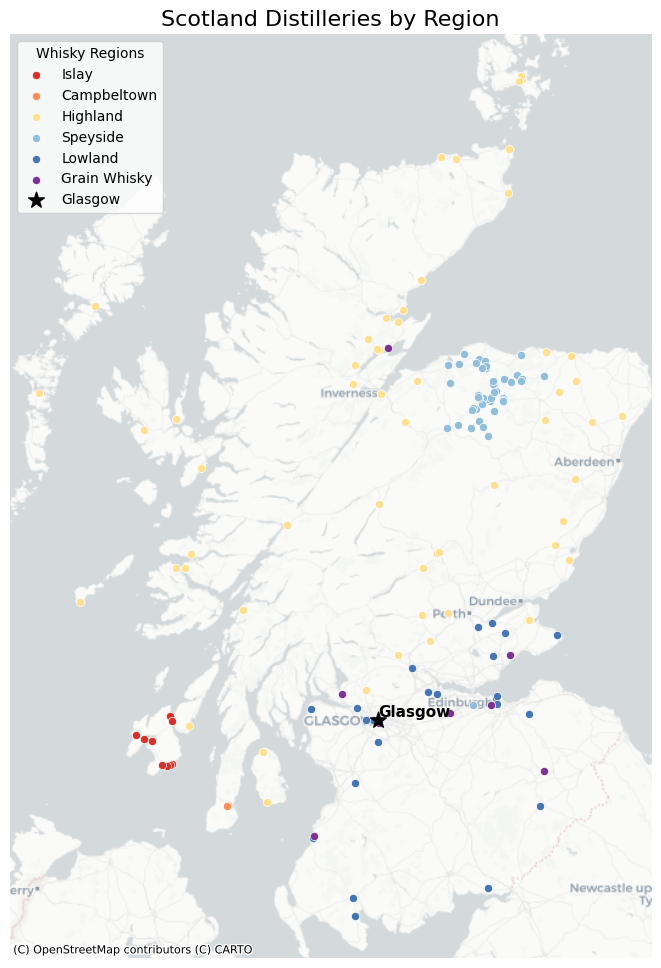

Map plotting completed.
Total distilleries in dataset: 152
Distilleries with valid coordinates: 152
Distilleries missing coordinates: 0


In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from geopy.geocoders import Nominatim

# load dataset
input_file = "scotland_distilleries_fully_merged.csv"
df = pd.read_csv(input_file)

required_columns = ["distillery_name", "easting", "northing"]
for col in required_columns:
    if col not in df.columns:
        raise ValueError(f"Column '{col}' not found in the dataset")

# region classification lists
islay_distilleries = [
    "Ardbeg Distillery", "Ardnahoe Distillery", "Bowmore Distillery",
    "Bruichladdich Distillery", "Bunnahabhain Distillery",
    "Caol Ila Distillery", "Kilchoman Distillery",
    "Lagavulin Distillery", "Laphroaig Distillery", "Port Ellen Distillery"
]

campbeltown_distilleries = [
    "Glen Scotia Distillery", "Glengyle Distillery", "Springbank Distillery"
]

highland_distilleries = [
    "8 Doors Distillery", "Aberfeldy Distillery", "Arbikie Distillery",
    "Ardmore Distillery", "Ardnamurchan Distillery", "Ardross Distillery",
    "Balblair Distillery", "Balmaud Distillery", "Ben Nevis Distillery",
    "Benbecula Distillery", "Blair Athol Distillery", "Brora Distillery",
    "Burn o'Bennie Distillery", "Clynelish Distillery", "Dalmore Distillery",
    "Dalwhinnie Distillery", "Deanston Distillery", "Dornoch Distillery",
    "Eden Mill Distillery", "Edradour Distillery", "Fettercairn Distillery",
    "Glen Garioch Distillery", "Glen Ord Distillery", "GlenWyvis Distillery",
    "Glencadam Distillery", "Glendronach, The Distillery",
    "Glenglassaugh Distillery", "Glengoyne Distillery",
    "Glenmorangie Distillery", "Glenturret, The Distillery",
    "Highland Park Distillery", "Isle of Harris Distillery",
    "Isle of Jura Distillery", "Isle of Raasay Distillery",
    "Isle of Tiree Distillery", "Lagg Distillery",
    "Loch Lomond Malt Distillery", "Lochranza Distillery",
    "Macduff Distillery", "Ncn'ean Distillery",
    "North Point Distillery", "Oban Distillery", "Orkney Distillery",
    "Pulteney Distillery", "Royal Brackla Distillery",
    "Royal Lochnagar Distillery", "Scapa Distillery",
    "Strathearn Distillery", "Talisker Distillery",
    "Teaninich Distillery", "Tobermory Distillery",
    "Tomatin Distillery", "Torabhaig Distillery",
    "Tullibardine Distillery", "Uile-bheist Distillery",
    "Wolfburn Distillery", "BrewDog Distilling Co Distillery"
]

speyside_distilleries = [
    "Aberlour Distillery", "Allt a' Bhainne Distillery",
    "Auchroisk Distillery", "Aultmore Distillery",
    "Ballindalloch Distillery", "Balmenach Distillery",
    "Balvenie, The Distillery", "BenRiach Distillery",
    "Benrinnes Distillery", "Benromach Distillery",
    "Braeval Distillery", "Cairn Distillery, The Distillery",
    "Cardhu Distillery", "Cragganmore Distillery",
    "Craigellachie Distillery", "Dailuaine Distillery",
    "Dalmunach Distillery", "Dufftown Distillery",
    "Dunphail Distillery", "Glen Elgin Distillery",
    "Glen Grant Distillery", "Glen Keith Distillery",
    "Glen Moray Distillery", "Glen Spey Distillery",
    "GlenAllachie Distillery", "Glenburgie Distillery",
    "Glendullan Distillery", "Glenfarclas Distillery",
    "Glenfiddich Distillery", "Glenlivet, The Distillery",
    "Glenlossie Distillery", "Glenrothes Distillery",
    "Glentauchers Distillery", "Inchgower Distillery",
    "Kininvie Distillery", "Knockando Distillery",
    "Knockdhu Distillery", "Linkwood Distillery",
    "Longmorn Distillery", "Macallan, The Distillery",
    "Mannochmore Distillery", "Miltonduff Distillery",
    "Mortlach Distillery", "Roseisle Distillery",
    "Speyburn Distillery", "Strathisla Distillery",
    "Strathmill Distillery", "Tamdhu Distillery",
    "Tamnavulin Distillery", "Tomintoul Distillery",
    "Tormore Distillery"
]

lowland_distilleries = [
    "Aberargie Distillery", "Ailsa Bay Distillery",
    "Annandale Distillery", "Ardgowan Distillery",
    "Auchentoshan Distillery", "Bladnoch Distillery",
    "Bonnington Distillery", "Borders Distillery",
    "Clydeside Distillery", "Crafty Distillery",
    "Daftmill Distillery", "Falkirk Distillery",
    "Glasgow Distillery", "Glenkinchie Distillery",
    "Holyrood Distillery", "InchDairnie Distillery",
    "Jackton Distillery", "Kingsbarns Distillery",
    "Lindores Abbey Distillery", "Lochlea Distillery",
    "Port of Leith Distillery", "Rosebank Distillery",
    "Stirling Distillery"
]

grain_distilleries = [
    "Cameronbridge Distillery", "Girvan Distillery",
    "Invergordon Distillery", "Loch Lomond Grain Distillery",
    "North British Distillery", "Reivers Distillery",
    "Starlaw Distillery", "Strathclyde Distillery"
]

# assign region
def assign_region(name):
    if name in islay_distilleries:
        return "Islay"
    elif name in campbeltown_distilleries:
        return "Campbeltown"
    elif name in highland_distilleries:
        return "Highland"
    elif name in speyside_distilleries:
        return "Speyside"
    elif name in lowland_distilleries:
        return "Lowland"
    elif name in grain_distilleries:
        return "Grain Whisky"
    else:
        return "Unmatched"

df["region"] = df["distillery_name"].apply(assign_region)

# create distillery GeoDataFrame
df_clean = df.dropna(subset=["easting", "northing"]).copy()

gdf = gpd.GeoDataFrame(
    df_clean,
    geometry=gpd.points_from_xy(df_clean["easting"], df_clean["northing"]),
    crs="EPSG:27700"
)

glasgow_df = pd.DataFrame({
    "name": ["Glasgow"],
    "lon": [-4.2518],
    "lat": [55.8642]
})

glasgow_gdf = gpd.GeoDataFrame(
    glasgow_df,
    geometry=gpd.points_from_xy(glasgow_df["lon"], glasgow_df["lat"]),
    crs="EPSG:4326"
)

glasgow_bng = glasgow_gdf.to_crs(epsg=27700)

# convert layers
gdf_web = gdf.to_crs(epsg=3857)
glasgow_web = glasgow_bng.to_crs(epsg=3857)

# color scheme
region_colors = {
    "Islay": "#d73027",
    "Campbeltown": "#fc8d59",
    "Highland": "#fee090",
    "Speyside": "#91bfdb",
    "Lowland": "#4575b4",
    "Grain Whisky": "#7b3294",
    "Unmatched": "#999999"
}

# plot map
fig, ax = plt.subplots(figsize=(14, 12))

for region, color in region_colors.items():
    region_data = gdf_web[gdf_web["region"] == region]
    if len(region_data) > 0:
        region_data.plot(
            ax=ax,
            markersize=35,
            color=color,
            label=region,
            edgecolor="white",
            linewidth=0.5
        )

# add Glasgow point
glasgow_web.plot(
    ax=ax,
    color="black",
    markersize=140,
    marker="*",
    label="Glasgow"
)

# add Glasgow label
for x, y, label in zip(
    glasgow_web.geometry.x,
    glasgow_web.geometry.y,
    glasgow_web["name"]
):
    ax.text(
        x, y, label,
        fontsize=11,
        weight="bold",
        ha="left",
        va="bottom"
    )

# add basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

# map decoration
ax.legend(title="Whisky Regions")
ax.set_title("Scotland Distilleries by Region", fontsize=16)
ax.set_axis_off()

plt.show()

print("Map plotting completed.")
print(f"Total distilleries in dataset: {len(df)}")
print(f"Distilleries with valid coordinates: {len(df_clean)}")
print(f"Distilleries missing coordinates: {len(df) - len(df_clean)}")

To understand the spatial structure of the dataset, the distillery points were visualised on the graph. The report retrieved the coordinates of Glasgow by connecting to OSM via an API, and converted them into the British National Grid to ensure consistency with the other spatial data in the following analysis.

The graph shows a clear spatial pattern. Speyside distilleries form a dense cluster in northeastern Scotland, Islay distilleries are concentrated on the western islands, and Lowland distilleries are distributed more closely around the Central Belt. Highland distilleries are the most widely dispersed across northern and western Scotland. The graph shows that the spatial distribution of distilleries is uneven and regionally differentiated.

## 3.Spatial Distribution
### 3.1 Road Network Preparation
#### 3.1.1 Road Network Data

In [8]:
import geopandas as gpd
import pandas as pd
import numpy as np
import re

# load roads shapefile
roads_path = r"C:\Users\84966\Desktop\course material\Programming Tools for Urban Analytics\Assignment\scotland-260325-free.shp\gis_osm_roads_free_1.shp"
roads = gpd.read_file(roads_path)
roads.head()

,osm_id,code,fclass,name,ref,oneway,maxspeed,layer,bridge,tunnel,geometry
0,137,5122,residential,Great King Street,NaN,B,32,0,F,F,"LINESTRING (-3.19957 55.95782, -3.19936 55.957..."
1,370,5131,motorway_link,NaN,M9,F,112,0,F,F,"LINESTRING (-3.41038 55.94936, -3.40826 55.94742)"
2,375,5131,motorway_link,NaN,M8,F,112,0,F,F,"LINESTRING (-3.30997 55.92267, -3.31006 55.922..."
3,1473,5122,residential,Tweedsmuir Crescent,NaN,B,32,0,F,F,"LINESTRING (-4.33385 55.92826, -4.3337 55.9284..."
4,1474,5122,residential,Argyll Road,NaN,B,32,0,F,F,"LINESTRING (-4.33467 55.92782, -4.33491 55.928..."


In [9]:
# use British National Grid
uk_crs = "EPSG:27700"

# road network
roads_proj = roads.to_crs(uk_crs)

# distillery points
dist_gdf_proj = gpd.GeoDataFrame(
    df_clean.copy(),
    geometry=gpd.points_from_xy(
        df_clean["easting"],
        df_clean["northing"]
    ),
    crs=uk_crs
)

# Glasgow point
glasgow_gdf = gpd.GeoDataFrame(
    {"name": ["Glasgow"]},
    geometry=gpd.points_from_xy(
        [location.longitude],
        [location.latitude]
    ),
    crs="EPSG:4326"
)

glasgow_proj = glasgow_gdf.to_crs(uk_crs)

print("CRS conversion complete")
print("Road CRS:", roads_proj.crs)
print("Distillery CRS:", dist_gdf_proj.crs)
print("Glasgow CRS:", glasgow_proj.crs)

CRS conversion complete
Road CRS: EPSG:27700
Distillery CRS: EPSG:27700
Glasgow CRS: EPSG:27700


The road network data were downloaded from OpenStreetMap in shapefile format. The dataset includes road class, road name, direction, speed limit and geometry information. To make the different spatial datasets comparable, the road network, distillery locations and Glasgow were all converted to British National Grid.

#### 3.1.2 Road Geometry

In [10]:
# clean road geometries
roads_net = roads_proj.copy()

roads_net = roads_net[
    roads_net.geometry.notna() &
    roads_net.geometry.geom_type.isin(["LineString", "MultiLineString"])
].copy()

roads_net = roads_net.explode(index_parts=False).reset_index(drop=True)

roads_net = roads_net[roads_net.geometry.geom_type == "LineString"].copy()

# calculate road lengths
roads_net["length_m"] = roads_net.geometry.length

print("Number of road segments:", len(roads_net))

Number of road segments: 872019


The road data were cleaned before network analysis. Features with missing geometry were removed. Multi-part features were then split into individual line segments. After cleaning process, the dataset contained 872,019 road segments.

#### 3.1.3 Travel Time Estimation

In [11]:
# estimate speed and travel time
def parse_speed_to_kph(value):
    if pd.isna(value):
        return np.nan
    
    text = str(value).strip().lower()
    
    if text in ["", "none", "nan", "0", "0.0"]:
        return np.nan
    
    m = re.search(r"\d+(\.\d+)?", text)
    if not m:
        return np.nan
    
    speed = float(m.group())
    
    if speed <= 0:
        return np.nan
    
    if "mph" in text:
        speed = speed * 1.60934
    
    return speed

roads_net["speed_kph_raw"] = roads_net["maxspeed"].apply(parse_speed_to_kph)

default_speed = {
    "motorway": 112,
    "motorway_link": 80,
    "trunk": 96,
    "trunk_link": 64,
    "primary": 80,
    "primary_link": 64,
    "secondary": 64,
    "secondary_link": 48,
    "tertiary": 48,
    "tertiary_link": 40,
    "residential": 32,
    "unclassified": 32,
    "service": 24,
    "living_street": 16
}

roads_net["speed_kph"] = roads_net["speed_kph_raw"]
mask = roads_net["speed_kph"].isna()
roads_net.loc[mask, "speed_kph"] = roads_net.loc[mask, "fclass"].map(default_speed)
roads_net["speed_kph"] = roads_net["speed_kph"].fillna(40)
roads_net.loc[roads_net["speed_kph"] <= 0, "speed_kph"] = 40

# travel time in minutes
roads_net["travel_time_min"] = (
    roads_net["length_m"] /
    1000 /
    roads_net["speed_kph"] * 60
)

# check for any infinite values
print("Any infinite:", np.isinf(roads_net["travel_time_min"]).any())

roads_net[[
    "fclass",
    "maxspeed",
    "speed_kph",
    "length_m",
    "travel_time_min"
]].head()

Any infinite: False


,fclass,maxspeed,speed_kph,length_m,travel_time_min
0,residential,32,32.0,205.510339,0.385332
1,motorway_link,112,112.0,253.143393,0.135613
2,motorway_link,112,112.0,694.186497,0.371886
3,residential,32,32.0,199.551933,0.374160
4,residential,32,32.0,161.382307,0.302592


Travel time was estimated from the maxspeed field. The speed values in OSM were not always stored in the same format, a parsing function was used to extract valid speed values and convert miles per hour to kilometres per hour where necessary. For segments with missing speed information, default speeds were assigned according to road type. Calculate the travel time for each segment based on the road length and speed. After the calculation is completed, check if there is any infinite time remaining and confirm that all sections have been calculated.

### 3.2 Road Network Construction and Spatial Visualisation
#### 3.2.1 Road Network Graph Construction

In [12]:
import networkx as nx

# build graph
G = nx.DiGraph()
for _, row in roads_net.iterrows():
    line = row.geometry
    coords = list(line.coords)
    start = tuple(coords[0])
    end = tuple(coords[-1])
    length_m = row["length_m"]
    travel_time_min = row["travel_time_min"]
    road_name = row["name"]
    fclass = row["fclass"]
    oneway = str(row["oneway"]).strip().upper() if pd.notna(row["oneway"]) else "B"

    # add edge in the forward direction
    G.add_edge(
        start,
        end,
        length_m=length_m,
        travel_time_min=travel_time_min,
        name=road_name,
        fclass=fclass
    )

    # add edge in the reverse direction for non-oneway roads
    if oneway not in ["T", "YES", "1", "TRUE"]:
        G.add_edge(
            end,
            start,
            length_m=length_m,
            travel_time_min=travel_time_min,
            name=road_name,
            fclass=fclass
        )

print("Graph rebuilt")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Graph rebuilt
Nodes: 1339669
Edges: 1724564


The cleaned road dataset was converted into a directed graph. Each road segment was treated as an edge, and the start and end coordinates of the segment were used as nodes. One-way roads were handled by only keeping the permitted travel direction. The graph contained 1339669 nodes and 1724564 edges.

#### 3.2.2 Main Connected Component Extraction

In [13]:
# keep largest connected component
largest_cc = max(
    nx.connected_components(G.to_undirected()),
    key=len
)

G_main = G.subgraph(largest_cc).copy()

print("Largest component nodes:", G_main.number_of_nodes())
print("Largest component edges:", G_main.number_of_edges())

Largest component nodes: 138036
Largest component edges: 300694


Not all parts of the Scottish road system are directly connected to the mainland network. To avoid errors in shortest-path calculation, only the largest connected component was kept for the accessibility analysis. 

#### 3.2.3 Spatial Visualisation

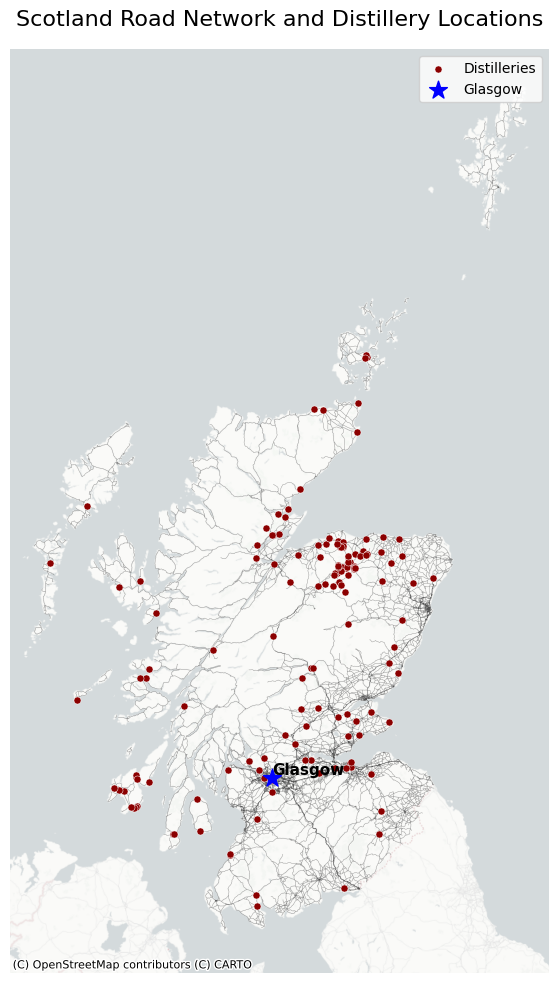

In [14]:
import matplotlib.pyplot as plt
import contextily as ctx

# keep only major roads
major_classes = [
    "motorway", "motorway_link",
    "trunk", "trunk_link",
    "primary", "primary_link",
    "secondary", "secondary_link",
    "tertiary", "tertiary_link"
]

# use harmonised BNG dataset first
roads_major = roads_proj[roads_proj["fclass"].isin(major_classes)].copy()

# convert to Web Mercator only for visualisation
roads_major_web = roads_major.to_crs(epsg=3857)
dist_web = dist_gdf_proj.to_crs(epsg=3857)
glasgow_web = glasgow_proj.to_crs(epsg=3857)

# plot
fig, ax = plt.subplots(figsize=(14, 12))

# major roads
roads_major_web.plot(
    ax=ax,
    linewidth=0.35,
    color="#555555",
    alpha=0.55,
    zorder=1
)

# distilleries
dist_web.plot(
    ax=ax,
    color="#8B0000",
    markersize=26,
    edgecolor="white",
    linewidth=0.35,
    label="Distilleries",
    zorder=3
)

# Glasgow
glasgow_web.plot(
    ax=ax,
    color="blue",
    marker="*",
    markersize=180,
    label="Glasgow",
    zorder=4
)

# Glasgow label
for x, y in zip(glasgow_web.geometry.x, glasgow_web.geometry.y):
    ax.text(
        x, y,
        "Glasgow",
        fontsize=11,
        weight="bold",
        ha="left",
        va="bottom",
        color="black",
        zorder=5
    )

# basemap
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.PositronNoLabels
)

ax.set_title("Scotland Road Network and Distillery Locations", fontsize=16)
ax.legend()
ax.set_axis_off()

plt.show()

The graph displays the Scottish road network, distillery locations and Glasgow. Roads are dense around the central belt and eastern Scotland, but become much sparser in the highlands and island areas. Many distilleries are located in peripheral areas of the network, which explains why some distilleries are less accessible from Glasgow.

### 3.3 Network-based Distance from Glasgow
#### 3.3.1 Nearest Network Node Identification

In [15]:
from shapely.geometry import Point
import geopandas as gpd

# build node GeoDataFrame
main_nodes = list(G_main.nodes)
nodes_main_gdf = gpd.GeoDataFrame(
    {"node": main_nodes},
    geometry=[Point(xy) for xy in main_nodes],
    crs=uk_crs
)

In [16]:
# find nearest node for Glasgow
glasgow_point = glasgow_proj.geometry.iloc[0]
glasgow_distances = nodes_main_gdf.geometry.distance(glasgow_point)
glasgow_node_main = nodes_main_gdf.loc[glasgow_distances.idxmin(), "node"]

print("Nearest Glasgow node:", glasgow_node_main)

Nearest Glasgow node: (259254.17950131427, 665353.8805179894)


In [17]:
# find nearest node for each distillery
nearest_nodes_main = []
nearest_node_dist_m = []

for _, row in dist_gdf_proj.iterrows():
    point = row.geometry
    dists = nodes_main_gdf.geometry.distance(point)
    idx = dists.idxmin()

    nearest_node = nodes_main_gdf.loc[idx, "node"]
    nearest_dist = dists.loc[idx]

    nearest_nodes_main.append(nearest_node)
    nearest_node_dist_m.append(nearest_dist)

dist_gdf_proj["nearest_node_main"] = nearest_nodes_main
dist_gdf_proj["snap_dist_to_network_m"] = nearest_node_dist_m
dist_gdf_proj[[
    "distillery_name",
    "nearest_node_main",
    "snap_dist_to_network_m"
]].head()

,distillery_name,nearest_node_main,snap_dist_to_network_m
0,8 Doors Distillery,"(338046.92148128035, 973284.7720245698)",42.915600
1,Aberargie Distillery,"(316667.23115257506, 715872.7835674819)",132.147998
2,Aberfeldy Distillery,"(286635.8992652669, 749570.4358208665)",39.506719
3,Aberlour Distillery,"(326363.68270288827, 842667.0910944692)",185.731933
4,Ailsa Bay Distillery,"(219325.6346001554, 600233.4709607548)",532.053887


Before calculating shortest paths, Glasgow and each distillery were linked to the nearest node in the main road network. The nearest road node to Glasgow was identified first, and the same method was then applied to all distilleries. The distance from each distillery to its nearest network node was also recorded.

#### 3.3.2 Driving Distance and Time Calculation

In [18]:
# compute drive distance and time
drive_distance_main = []
drive_time_main = []

for _, row in dist_gdf_proj.iterrows():
    target_node = row["nearest_node_main"]
    snap_dist = row["snap_dist_to_network_m"]

    if snap_dist > 5000:
        drive_distance_main.append(np.nan)
        drive_time_main.append(np.nan)
        continue

    try:
        d = nx.shortest_path_length(
            G_main,
            source=glasgow_node_main,
            target=target_node,
            weight="length_m"
        )

        t = nx.shortest_path_length(
            G_main,
            source=glasgow_node_main,
            target=target_node,
            weight="travel_time_min"
        )

    except nx.NetworkXNoPath:
        d = np.nan
        t = np.nan

    drive_distance_main.append(d)
    drive_time_main.append(t)

dist_gdf_proj["drive_distance_from_glasgow"] = drive_distance_main
dist_gdf_proj["drive_time_from_glasgow"] = drive_time_main
dist_gdf_proj["drive_distance_km"] = dist_gdf_proj["drive_distance_from_glasgow"] / 1000
dist_gdf_proj["drive_time_hr"] = dist_gdf_proj["drive_time_from_glasgow"] / 60
dist_gdf_proj[[
    "distillery_name",
    "drive_distance_from_glasgow",
    "drive_time_from_glasgow",
    "drive_distance_km",
    "drive_time_hr"
]].head(10)

,distillery_name,drive_distance_from_glasgow,drive_time_from_glasgow,drive_distance_km,drive_time_hr
0,8 Doors Distillery,444820.914698,307.459703,444.820915,5.124328
1,Aberargie Distillery,102042.757522,67.627676,102.042758,1.127128
2,Aberfeldy Distillery,119124.700516,80.825807,119.124701,1.347097
3,Aberlour Distillery,252627.568858,172.173412,252.627569,2.869557
4,Ailsa Bay Distillery,108313.799617,110.922667,108.313800,1.848711
5,Allt a' Bhainne Distillery,239700.590004,173.725558,239.700590,2.895426
6,Annandale Distillery,153094.940121,91.925458,153.094940,1.532091
7,Arbikie Distillery,168148.292604,110.443187,168.148293,1.840720
8,Ardbeg Distillery,NaN,NaN,NaN,NaN
9,Ardgowan Distillery,55212.581645,50.216783,55.212582,0.836946


In [19]:
# check results
print("Valid distance values:",
      dist_gdf_proj["drive_distance_from_glasgow"].notna().sum())

print("Missing distance values:",
      dist_gdf_proj["drive_distance_from_glasgow"].isna().sum())

print("Infinite time values:",
      np.isinf(dist_gdf_proj["drive_time_from_glasgow"]).sum())

print("Missing time values:",
      dist_gdf_proj["drive_time_from_glasgow"].isna().sum())

Valid distance values: 130
Missing distance values: 22
Infinite time values: 0
Missing time values: 22


Driving distance and driving time from Glasgow were calculated using shortest-path analysis. For each distillery, the shortest path from Glasgow to the nearest road node of that distillery was calculated. Valid accessibility results were obtained for 130 distilleries. For the other 22 distilleries, driving distance and time were missing. 

#### 3.3.3 Missing Distilleries

In [20]:
# identify distilleries with missing drive distance
missing_distilleries = dist_gdf_proj.loc[
    dist_gdf_proj["drive_distance_from_glasgow"].isna(),
    ["distillery_name", "snap_dist_to_network_m"]
]

# sort by distance from road network
missing_distilleries = missing_distilleries.sort_values(
    by="snap_dist_to_network_m",
    ascending=False
)

# display summary
print(f"Number of distilleries with missing drive distance: {missing_distilleries.shape[0]}")
missing_distilleries.head(5)

Number of distilleries with missing drive distance: 22


,distillery_name,snap_dist_to_network_m
96,Isle of Tiree Distillery,53368.870843
98,Kilchoman Distillery,48872.396792
35,Bruichladdich Distillery,44414.562604
31,Bowmore Distillery,39697.021563
122,Orkney Distillery,37901.036556


The missing values mainly come from distilleries located in Islay, Orkney and other islands, such as Ardbeg, Bowmore and Highland Park distilleries. These sites are not fully connected to the mainland road system and often require ferry travel to complete the journey. This indicates that the missing values are mainly due to the geographical distance from the mainland road network.

### 3.4 Accessibility Classification and Spatial Patterns

In [21]:
# check accessibility variables
print(dist_gdf_proj[[
    "distillery_name",
    "drive_distance_km",
    "drive_time_hr"
]].columns.tolist())

['distillery_name', 'drive_distance_km', 'drive_time_hr']


In [22]:
# create drive time classes
bins = [0, 1, 2, 3, 4, 10]
labels = [
    "0–1 hr",
    "1–2 hr",
    "2–3 hr",
    "3–4 hr",
    "4+ hr"
]

dist_gdf_proj["drive_time_class"] = pd.cut(
    dist_gdf_proj["drive_time_hr"],
    bins=bins,
    labels=labels
)

In [23]:
# color scheme
time_colors = {
    "0–1 hr": "#2c7bb6",
    "1–2 hr": "#abd9e9",
    "2–3 hr": "#ffffbf",
    "3–4 hr": "#fdae61",
    "4+ hr": "#d7191c"
}

In [24]:
# convert to web mercator
dist_web = dist_gdf_proj.to_crs(epsg=3857)
glasgow_web = glasgow_gdf.to_crs(epsg=3857)
roads_web = roads_major.to_crs(epsg=3857)

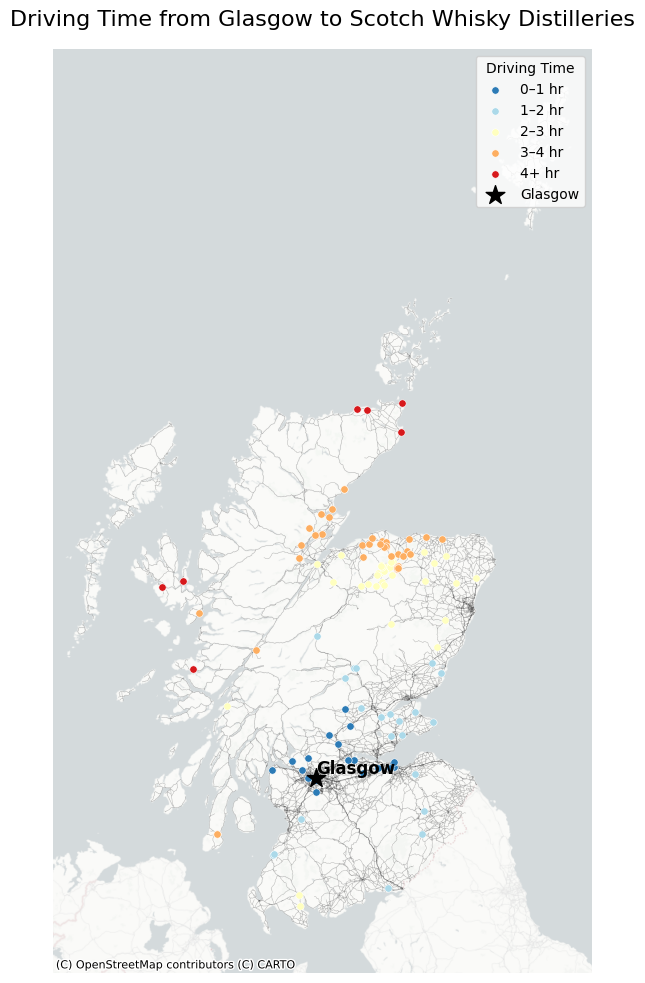

In [25]:
# plot driving time map
fig, ax = plt.subplots(figsize=(14, 12))

# roads
roads_web.plot(
    ax=ax,
    linewidth=0.35,
    color="#666666",
    alpha=0.45,
    zorder=1
)

# plot distilleries by class
for category, color in time_colors.items():
    
    subset = dist_web[
        dist_web["drive_time_class"] == category
    ]

    if len(subset) > 0:
        subset.plot(
            ax=ax,
            color=color,
            markersize=28,
            edgecolor="white",
            linewidth=0.4,
            label=category,
            zorder=3
        )

# Glasgow
glasgow_web.plot(
    ax=ax,
    color="black",
    marker="*",
    markersize=200,
    label="Glasgow",
    zorder=4
)

# Glasgow label
for x, y in zip(
    glasgow_web.geometry.x,
    glasgow_web.geometry.y
):
    ax.text(
        x,
        y,
        "Glasgow",
        fontsize=12,
        weight="bold",
        ha="left",
        va="bottom"
    )

# basemap
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.PositronNoLabels
)

ax.set_title(
    "Driving Time from Glasgow to Scotch Whisky Distilleries",
    fontsize=16
)

ax.legend(
    title="Driving Time"
)

ax.set_axis_off()
plt.show()

Driving time was grouped into five classes: 0–1 hour, 1–2 hours, 2–3 hours, 3–4 hours, and over 4 hours. The figure shows a clear spatial pattern in accessibility from Glasgow.

The shortest travel times are mainly concentrated around Glasgow and the central belt. Distilleries within 0–1 hour and 1–2 hours are mostly found in the Lowland region and other nearby parts of southern Scotland, where the road network is denser and more directly connected to Glasgow. The distilleries with longer driving times are concentrated further north. Many sites in the highlands and speyside fall into the 2–3 hour and 3–4 hour groups, while the most remote mainland distilleries are in the 4+ hour category.

The graph shows that accessibility decreases with distance from Glasgow and with weaker road connectivity in more peripheral parts of Scotland. Distilleries closer to Glasgow and the main road network are easier to reach, while those in northern and western parts of Scotland are less accessible.

### 3.5 Statistical Analysis of Accessibility
#### 3.5.1 Summary Statistics

In [26]:
dist_gdf_proj["drive_time_hr"].describe()

count    130.000000
mean       2.501594
std        1.167592
min        0.079457
25%        1.456388
50%        2.864108
75%        3.223137
max        5.124328
Name: drive_time_hr, dtype: float64

After excluding missing values, 130 distilleries were included in the accessibility analysis. The mean driving time from Glasgow was 2.50 hours, with a minimum of 0.08 hours and a maximum of 5.12 hours. The standard deviation of 1.17 hours indicates clear variation in accessibility across the dataset.

In [27]:
# count by drive time class
dist_gdf_proj.groupby("drive_time_class").size()

drive_time_class
0–1 hr    21
1–2 hr    21
2–3 hr    39
3–4 hr    42
4+ hr      7
dtype: int64

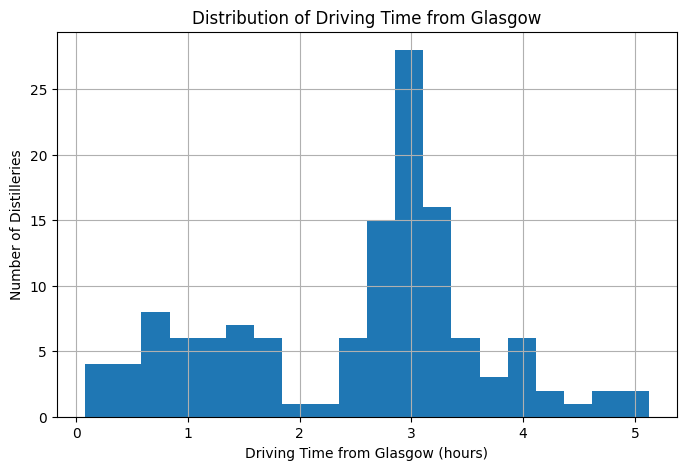

In [28]:
import matplotlib.pyplot as plt

# Histogram
plt.figure(figsize=(8,5))
dist_gdf_proj["drive_time_hr"].hist(
    bins=20
)

plt.xlabel("Driving Time from Glasgow (hours)")
plt.ylabel("Number of Distilleries")
plt.title("Distribution of Driving Time from Glasgow")
plt.show()

The figure shows that most distilleries are concentrated between about 2 and 4 hours from Glasgow, with a peak near 3 hours. Fewer distilleries are located within the shortest travel times, and only a small number fall into the most remote category.

When grouped into classes, 21 distilleries were within 0–1 hour, 21 within 1–2 hours, 39 within 2–3 hours, 42 within 3–4 hours, and 7 above 4 hours. This shows that most distilleries are located at moderate travel times rather than very close to Glasgow.

#### 3.5.2 Distillery-level Regression Analysis

In [29]:
import statsmodels.api as sm

# use all distilleries with valid values only
reg_df = dist_gdf_proj.dropna(subset=["drive_time_hr", "drive_distance_km"]).copy()

# dependent and independent variables
y = reg_df["drive_time_hr"]
X = reg_df[["drive_distance_km"]]

# add constant
X = sm.add_constant(X)

# fit OLS model
model = sm.OLS(y, X).fit()

print("Number of distilleries used in regression:", len(reg_df))
print(model.summary())

Number of distilleries used in regression: 130
                            OLS Regression Results                            
Dep. Variable:          drive_time_hr   R-squared:                       0.940
Model:                            OLS   Adj. R-squared:                  0.939
Method:                 Least Squares   F-statistic:                     1996.
Date:                Sun, 29 Mar 2026   Prob (F-statistic):           6.04e-80
Time:                        19:49:52   Log-Likelihood:                -21.508
No. Observations:                 130   AIC:                             47.02
Df Residuals:                     128   BIC:                             52.75
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

To provide a simple descriptive check of the relationship between network distance and travel time, an OLS regression was carried out at the distillery level. Only distilleries with valid accessibility results were included, so observations with missing values were removed before modelling. 

In the model, driving time from Glasgow was used as the dependent variable and driving distance from Glasgow was used as the explanatory variable. 

The regression results show a very strong positive relationship between the two variables, with an R-squared value of 0.940. This is expected because travel time is structurally related to network distance under the assumed road-speed conditions. The coefficient for driving distance is 0.0112, indicating that an increase of 1 kilometre in driving distance is associated with an increase of about 0.011 hours in driving time, or roughly 0.67 minutes. This relationship is statistically significant at the 1% level.

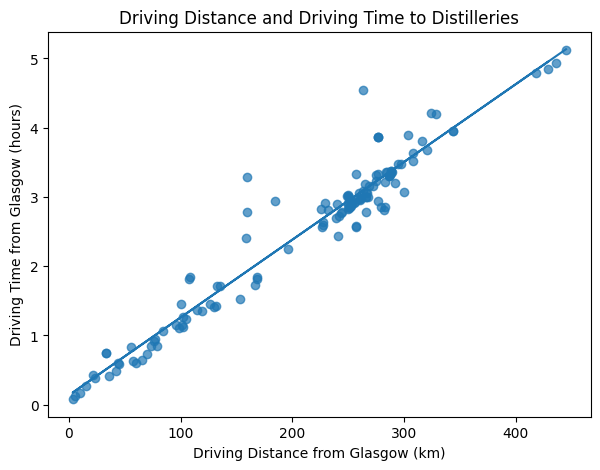

R² = 0.940


In [30]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

# data
x = reg_df["drive_distance_km"]
y = reg_df["drive_time_hr"]

# linear fit
coef = np.polyfit(x, y, 1)
poly1d_fn = np.poly1d(coef)

# plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x, y, alpha=0.7)
ax.plot(x, poly1d_fn(x))

ax.set_xlabel("Driving Distance from Glasgow (km)")
ax.set_ylabel("Driving Time from Glasgow (hours)")
ax.set_title("Driving Distance and Driving Time to Distilleries")

plt.show()

# R²
r2 = r2_score(y, poly1d_fn(x))
print(f"R² = {r2:.3f}")

The figure shows that the data points are closely distributed around the fitted regression line. For most distilleries, a longer network distance from Glasgow is directly associated with longer travel time.

The scatterplot also shows a small number of points lying further from the regression line. These cases suggest that some distilleries with similar driving distances may still have different travel times, because of differences in local network conditions. Although distance is the main factor explaining travel time in this model, it is not the only one.

The regression model confirms that network distance is a strong predictor of road accessibility from Glasgow.

## 4.Spatial Clustering Analysis

The purpose of the spatial clustering analysis is to test whether the accessibility of distilleries from Glasgow shows a meaningful spatial pattern. This analysis first defines neighbourhood relationships using a K-nearest neighbours (KNN) spatial weight matrix, then tests for overall spatial autocorrelation with Global Moran’s I, and identifies the location of significant local clusters through LISA.

### 4.1 Spatial Weight Matrix Construction

In [31]:
# prepare data
analysis_gdf = dist_gdf_proj.dropna(subset=["drive_time_hr"]).copy()

print("Number of distilleries used:", len(analysis_gdf))

Number of distilleries used: 130


In [32]:
from libpysal.weights import KNN

# spatial weights
w = KNN.from_dataframe(analysis_gdf, k=5)
w.transform = "R"

print(w.n)

130


The KNN spatial weight matrix was used to define the local neighbourhood structure among distilleries. Each distillery was linked to its five nearest neighbours. This approach is suitable for point data with uneven spatial distribution, which ensures that each observation has the same number of neighbours and avoids isolated observations in sparse areas.

### 4.2 Global Spatial Autocorrelation

In [33]:
from esda.moran import Moran

# Global Moran's I
y = analysis_gdf["drive_time_hr"].values
moran = Moran(y, w)

print("Global Moran's I:", moran.I)
print("p-value:", moran.p_sim)

Global Moran's I: 0.908970665196284
p-value: 0.001


c:\Users\84966\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


The result shows a Moran’s I value of 0.909 with a p-value of 0.001, indicating a very strong and statistically significant positive spatial autocorrelation in driving time from Glasgow.

### 4.3 Local Spatial Autocorrelation

In [34]:
from esda.moran import Moran_Local

# Local Moran's I
lisa = Moran_Local(y, w)
analysis_gdf["local_I"] = lisa.Is
analysis_gdf["p_value"] = lisa.p_sim
analysis_gdf["quadrant"] = lisa.q
analysis_gdf[[
    "distillery_name",
    "drive_time_hr",
    "local_I",
    "p_value",
    "quadrant"
]].head()

,distillery_name,drive_time_hr,local_I,p_value,quadrant
0,8 Doors Distillery,5.124328,3.833489,0.001,1
1,Aberargie Distillery,1.127128,1.335856,0.005,3
2,Aberfeldy Distillery,1.347097,1.170147,0.005,3
3,Aberlour Distillery,2.869557,0.100229,0.217,1
4,Ailsa Bay Distillery,1.848711,-0.034473,0.424,2


In [35]:
# create LISA cluster labels
def lisa_cluster(row):
    if row["p_value"] > 0.05:
        return "Not significant"
    elif row["quadrant"] == 1:
        return "High-High"
    elif row["quadrant"] == 2:
        return "Low-High"
    elif row["quadrant"] == 3:
        return "Low-Low"
    elif row["quadrant"] == 4:
        return "High-Low"
    else:
        return "Not significant"

analysis_gdf["lisa_cluster"] = analysis_gdf.apply(lisa_cluster, axis=1)
analysis_gdf["lisa_cluster"].value_counts()

lisa_cluster
Not significant    66
Low-Low            36
High-High          28
Name: count, dtype: int64

In [36]:
# LISA color scheme
lisa_colors = {
    "High-High": "#d7191c",
    "Low-Low": "#2c7bb6",
    "High-Low": "#fdae61",
    "Low-High": "#abd9e9",
    "Not significant": "#cccccc"
}

In [37]:
# convert for mapping
analysis_web = analysis_gdf.to_crs(epsg=3857)
glasgow_web = glasgow_gdf.to_crs(epsg=3857)
roads_web = roads_major.to_crs(epsg=3857)

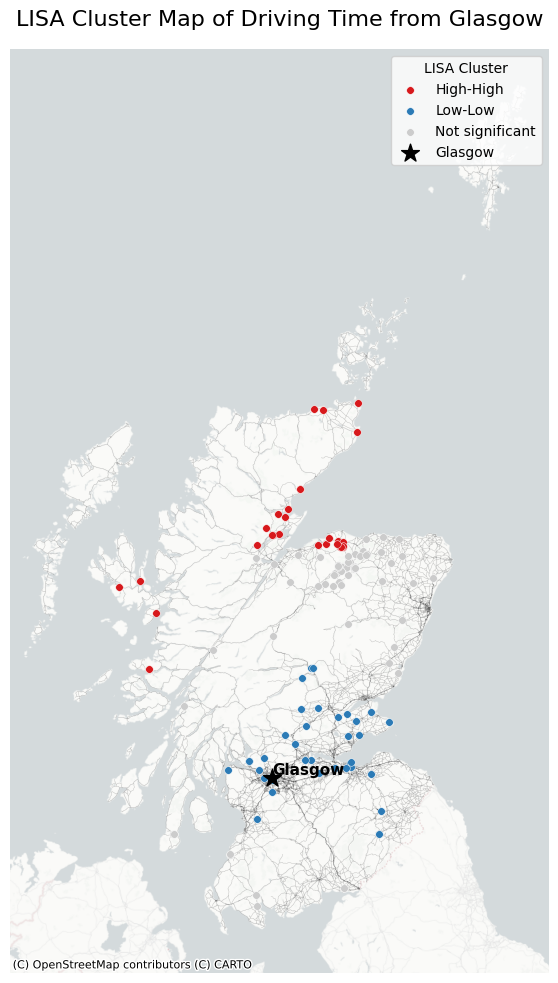

In [38]:
import matplotlib.pyplot as plt
import contextily as ctx

# plot LISA cluster map
fig, ax = plt.subplots(figsize=(14, 12))

# roads
roads_web.plot(
    ax=ax,
    linewidth=0.35,
    color="#666666",
    alpha=0.35,
    zorder=1
)

# distilleries by LISA cluster
for cluster, color in lisa_colors.items():
    subset = analysis_web[analysis_web["lisa_cluster"] == cluster]
    
    if len(subset) > 0:
        subset.plot(
            ax=ax,
            color=color,
            markersize=30,
            edgecolor="white",
            linewidth=0.35,
            label=cluster,
            zorder=3
        )

# Glasgow
glasgow_web.plot(
    ax=ax,
    color="black",
    marker="*",
    markersize=180,
    label="Glasgow",
    zorder=4
)

for x, y in zip(glasgow_web.geometry.x, glasgow_web.geometry.y):
    ax.text(
        x,
        y,
        "Glasgow",
        fontsize=11,
        weight="bold",
        ha="left",
        va="bottom"
    )

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.PositronNoLabels
)

ax.set_title("LISA Cluster Map of Driving Time from Glasgow", fontsize=16)
ax.legend(title="LISA Cluster")
ax.set_axis_off()

plt.show()

Local Moran’s I was used to examine where significant local clusters of accessibility are located. The LISA results show three main categories. 25 distilleries were classified as High-High, 36 distilleries as Low-Low, and 69 distilleries were not significant. No clear High-Low or Low-High outlier groups were identified. This displays that the local pattern is mainly characterised by clustering of similar values rather than isolated exceptions.

From this figure, High-High clusters are mainly located in northern Scotland, especially in parts of highland and speyside. These represent distilleries with long driving times surrounded by neighbours with similarly high values. In contrast, Low-Low clusters are concentrated around Glasgow and the central belt, where distilleries with shorter driving times are grouped together. The remaining non-significant distilleries are more scattered and do not form clear local clusters.

This result shows that accessibility from Glasgow is locally structured: lower-accessibility distilleries cluster in northern areas, while higher-accessibility distilleries cluster in the more connected south.

### 4.4 Significant Cluster Analysis

In [39]:
significant_clusters = analysis_gdf[
    analysis_gdf["lisa_cluster"] != "Not significant"
][[
    "distillery_name",
    "drive_time_hr",
    "region",
    "lisa_cluster"
]].sort_values(["lisa_cluster", "drive_time_hr"])

significant_clusters.head(5)

,distillery_name,drive_time_hr,region,lisa_cluster
26,Benromach Distillery,3.189113,Speyside,High-High
87,GlenWyvis Distillery,3.223748,Highland,High-High
62,Glen Elgin Distillery,3.305052,Speyside,High-High
112,Longmorn Distillery,3.305052,Speyside,High-High
107,Linkwood Distillery,3.318661,Speyside,High-High


The significant cluster results highlight a clear contrast between northern and southern Scotland. High-High clusters consist of distilleries with relatively long driving times from Glasgow that are located near neighbouring distilleries with similarly high values. Most of these distilleries are found in speyside and highland, indicating that lower accessibility is concentrated in the north and northeast.

The Low-Low clusters are mainly located closer to Glasgow and within the more connected southern road network. These distilleries have shorter driving times and are surrounded by similarly accessible neighbours. This suggests that accessibility is spatially organised into broad regional groupings rather than being randomly distributed across individual sites.

The results show that driving accessibility from Glasgow is not randomly distributed across distilleries. It displays a clear spatial clustering pattern. Distilleries with longer driving times tend to be located near other distilleries with similarly long travel times, while distilleries with shorter driving times are also grouped together. This means that accessibility is shaped not only by individual location, but also by broader spatial structure.

## 5.Spatial Patterns and Proximity Analysis
### 5.1 Accessibility Distribution Analysis

In [40]:
# distillery count by accessibility
accessibility_counts = dist_gdf_proj.groupby(
    "drive_time_class"
)["distillery_name"].count()

accessibility_counts

drive_time_class
0–1 hr    21
1–2 hr    21
2–3 hr    39
3–4 hr    42
4+ hr      7
Name: distillery_name, dtype: int64

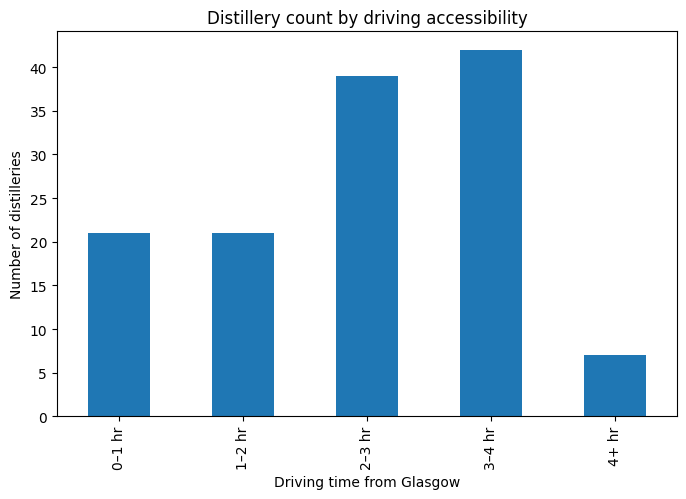

In [41]:
import matplotlib.pyplot as plt

accessibility_counts.plot(
    kind="bar",
    figsize=(8,5)
)

plt.xlabel("Driving time from Glasgow")
plt.ylabel("Number of distilleries")
plt.title("Distillery count by driving accessibility")

plt.show()

The distribution of driving time shows that most distilleries are not located very close to Glasgow. Among the distilleries with valid accessibility results, 21 distilleries fall within 0–1 hour, 21 distilleries within 1–2 hours, 39 distilleries within 2–3 hours, 42 distilleries within 3–4 hours, and 7 distilleries require more than 4 hours of driving time.

The largest number of distilleries falls in the 2–4 hour range. This means that Glasgow can reach many distilleries by driving, but for most of them the journey is not short. Only a relatively small number of distilleries are located within the most accessible range. This pattern is consistent with the earlier maps, which showed that distilleries are spread across Scotland rather than concentrated around the central belt.

This distribution analysis answers the driving accessibility from Glasgow. Distilleries are not evenly spread across all travel-time bands. They are concentrated in bands that represent medium to relatively long journeys, reflecting the fact that many whisky-producing areas are located outside Scotland’s main urban core.

### 5.2 Glasgow 50 km Buffer Analysis

In [42]:
# create Glasgow 50km buffer
glasgow_buffer = glasgow_proj.buffer(50000)

gpd.GeoSeries(glasgow_buffer).plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linestyle="--",
    linewidth=1.2,
    label="50km from Glasgow"
)

<Axes: title={'center': 'LISA Cluster Map of Driving Time from Glasgow'}>

In [43]:
# project layers to a metric CRS for distance analysis
glasgow_proj = glasgow_bng.to_crs(epsg=27700)
gdf_proj = gdf.to_crs(epsg=27700)

# create Glasgow 50km buffer
glasgow_buffer = glasgow_proj.buffer(50000)

gpd.GeoSeries(glasgow_buffer, crs=glasgow_proj.crs).plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linestyle="--",
    linewidth=1.2,
    label="50km from Glasgow"
)

# ensure buffer is in same CRS
buffer_gdf = gpd.GeoDataFrame(geometry=glasgow_buffer, crs=glasgow_proj.crs)
buffer_gdf = buffer_gdf.to_crs(gdf_proj.crs)

# spatial join
distilleries_near_glasgow = gpd.sjoin(
    gdf_proj,
    buffer_gdf,
    predicate="within"
)

print("Distilleries within 50km of Glasgow:", len(distilleries_near_glasgow))

Distilleries within 50km of Glasgow: 15


A 50 km buffer was created around Glasgow to test whether distilleries are concentrated in the city’s immediate surrounding area. The buffer is based on straight-line distance rather than actual travel routes. It provides a simple measure of proximity, but it does not replace the network-based accessibility analysis. This step was included to complement the road-based accessibility analysis with a simpler measure of spatial proximity.

The result shows that only 15 distilleries fall within 50 km of Glasgow. Compared with the full sample of 152 distilleries, this is a small share, suggesting that distilleries are not strongly clustered around the city. Most are located outside the near-Glasgow zone and are distributed across a much wider regional space.

## 6. Conclusion and Discussion

This report examined the road-based accessibility of distilleries from Glasgow using spatial data, road network analysis and spatial statistics. A geocoded dataset of 152 currently operating distilleries was constructed, and their accessibility was assessed using network-based distance, travel time and spatial clustering analysis.

The results show that distilleries are not strongly concentrated around Glasgow. The 50 km buffer analysis found that only 15 distilleries are located within this range, which is a small share of the full sample. 

This report also found clear differences in driving accessibility between distilleries. After data cleaning, 130 distilleries produced valid road-based accessibility results within the connected mainland network. Most fall within the 2–4 hour travel range from Glasgow, while fewer are located within the shortest travel-time bands. In addition, 22 distilleries returned missing values because they are located on islands or outside the connected mainland road network, which further highlights the uneven geography of accessibility in Scotland.

The spatial clustering analysis shows that accessibility is not randomly distributed. Global Moran’s I indicates strong positive spatial autocorrelation, while the LISA results identify clear clusters of high and low accessibility. Less accessible distilleries are mainly concentrated in northern parts of Scotland, especially Highland and Speyside, while more accessible clusters are found closer to Glasgow and the more connected southern mainland. This shows that accessibility is shaped by broader regional geography and network structure rather than by isolated site conditions alone.

The findings suggest that the distillery network is a nationally distributed cultural tourism resource. Traffic accessibility to distilleries depends  on regional location and road connectivity. From an urban perspective, this means that transport accessibility plays an important role in shaping how cultural tourism resources can be reached and experienced across Scotland.

This report also has some limitations. First, all operating distilleries on the SWA list were treated as tourism-relevant sites because complete visitor-centre data were not available. Second, island distilleries could not be fully represented in the mainland road network analysis because ferry links were not included. Thire, due to the data limitations, the regression analysis presented in this report is relatively simple. Future research could make use of richer transport and tourism data and develop more advanced regression or spatial modelling approaches.

## Reference

Boeing, G. (2025) ‘Modeling and analyzing urban networks and amenities with OSMnx’, Geographical Analysis, 57(4), pp. 567–577. doi:10.1111/gean.70009.

Iamtrakul, P., Chayphong, S., Seo, D. and Trinh, T.A. (2025) ‘Promoting accessibility for sustainable tourism: a spatial analysis of tourist attractions and public transportation networks in Bangkok’, City, Territory and Architecture. Available at: Springer.

Lättman, K., Friman, M. and Olsson, L.E. (2024) ‘Perceived accessibility: unveiling inequalities in transport justice’, Transport Policy. Available at: Taylor & Francis Online. 

Nominatim contributors (2026) Search API. Available at: Nominatim documentation website. 

OpenStreetMap contributors (2026) Copyright and licence. Available at: OpenStreetMap website. 

Scotch Whisky Association (2025) Facts & Figures. Available at: https://www.scotch-whisky.org.uk/industry-insights/facts-figures/?utm_source=chatgpt.com

Scotch Whisky Association (2026) Distillery map. Available at: https://www.scotch-whisky.org.uk/discover-scotch/distillery-map/

Yen, H.-P., Chen, P.-C. and Ho, K.-C. (2021) ‘Analyzing destination accessibility from the perspective of efficiency among tourism origin countries’, SAGE Open, 11(2). doi:10.1177/21582440211005752.

## Word Count

In [44]:
import io
import os
import re
from nbformat import current


def strip_references_section(text):
    if not text:
        return ""

    lines = text.splitlines()
    kept_lines = []

    for line in lines:
        normalized = line.strip().lower().rstrip(":")
        normalized = normalized.lstrip("#").strip()

        if normalized in {"reference", "references"}:
            break

        kept_lines.append(line)

    return "\n".join(kept_lines)


def remove_inline_references(text):
    if not text:
        return ""

    # Remove markdown reference link definitions
    text = re.sub(r'^\s*\[[^\]]+\]:\s+\S+.*$', '', text, flags=re.MULTILINE)

    # Remove inline citations like [1], [2], [12]
    text = re.sub(r'\[\d+(?:\s*,\s*\d+)*\]', '', text)

    return text


for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith(".ipynb") and not file.endswith("checkpoint.ipynb"):
            path = os.path.join(root, file)
            print(path)

            with io.open(path, "r", encoding="utf-8") as f:
                nb = current.read(f, "json")

            markdown_word_count = 0
            heading_word_count = 0
            code_word_count = 0

            for cell in nb.worksheets[0].cells:
                if cell.cell_type == "markdown":
                    text = cell.get("source", "")
                    text = strip_references_section(text)
                    text = remove_inline_references(text)
                    text = text.replace("#", " ").strip()
                    markdown_word_count += len(text.split())

                elif cell.cell_type == "heading":
                    text = cell.get("source", "")
                    text = strip_references_section(text)
                    text = remove_inline_references(text)
                    text = text.replace("#", " ").strip()
                    heading_word_count += len(text.split())

                elif cell.cell_type == "code":
                    text = cell.get("input", "")
                    text = strip_references_section(text)
                    text = remove_inline_references(text)
                    text = text.replace("#", " ").strip()
                    code_word_count += len(text.split())

            print("{} words in notebook markdown".format(markdown_word_count))
            print("{} words in notebook headings".format(heading_word_count))
            print("{} words in notebook code".format(code_word_count))

            break

    break

.\PTUA_Assignment_3075639.ipynb
3080 words in notebook markdown
85 words in notebook headings
4174 words in notebook code


C:\Users\84966\AppData\Local\Temp\ipykernel_27084\1947778250.py:4: DeprecationWarning: nbformat.current is deprecated since before nbformat 3.0

- use nbformat for read/write/validate public API
- use nbformat.vX directly to composing notebooks of a particular version

  from nbformat import current
